In [1]:
%pip freeze

aider-install==0.2.0
alembic==1.18.5
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
asttokens==3.0.2
certifi==2026.2.25
cffi==2.0.0
click==8.3.1
cloudpickle==3.1.2
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
coverage==7.15.2
cycler==0.12.1
debugpy==1.8.21
dnspython==2.8.0
email-validator==2.3.0
et_xmlfile==2.0.0
executing==2.2.1
fastapi==0.135.2
fastapi-cli==0.0.24
fastapi-cloud-cli==0.15.0
fastar==0.9.0
fonttools==4.64.0
greenlet==3.3.2
h11==0.16.0
httpcore==1.0.9
httptools==0.7.1
httpx==0.28.1
idna==3.11
iniconfig==2.3.0
interface_meta==2.0.1
ipykernel==7.3.0
ipython==9.17.1
ipython_pygments_lexers==1.1.1
jedi==0.20.0
Jinja2==3.1.6
joblib==1.6.0
jupyter_client==8.10.0
jupyter_core==5.9.1
kiwisolver==1.5.1
Mako==1.3.12
markdown-it-py==4.0.0
MarkupSafe==3.0.3
matplotlib==3.11.1
matplotlib-inline==0.2.2
mdurl==0.1.2
narwhals==2.25.0
nest-asyncio2==1.7.2
numpy==2.5.2
opencv-python==5.0.0.93
openpyxl==3.1.5
packaging==26.2
panda

In [2]:
# openpyxl est requis pour lire le .xlsx (absent du kernel) — a executer une seule fois
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

raw = pd.read_excel("amazon.xlsx", sheet_name="amazon")
raw.head()

,i,Quarter,Revenue,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,60,2005-03-31,1902,NaN,NaN,NaN,NaN
1,59,2005-06-30,1753,NaN,NaN,NaN,NaN
2,58,2005-09-30,1858,NaN,NaN,NaN,NaN
3,57,2005-12-31,2977,NaN,NaN,NaN,NaN
4,56,2006-03-31,2279,NaN,NaN,NaN,NaN


### 1.1 Structure : lignes, colonnes, types

In [5]:
print(f"Dimensions brutes : {raw.shape[0]} lignes x {raw.shape[1]} colonnes\n")
raw.info()

vides = [c for c in raw.columns if raw[c].isna().all()]
print(f"\nColonnes entierement vides : {vides}")
print("Colonne 'Unnamed: 6' (annotations parasites) :",
      raw["Unnamed: 6"].dropna().tolist())

Dimensions brutes : 61 lignes x 7 colonnes

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   i           61 non-null     int64         
 1   Quarter     61 non-null     datetime64[us]
 2   Revenue     61 non-null     int64         
 3   Unnamed: 3  0 non-null      float64       
 4   Unnamed: 4  0 non-null      float64       
 5   Unnamed: 5  0 non-null      float64       
 6   Unnamed: 6  2 non-null      str           
dtypes: datetime64[us](1), float64(3), int64(2), str(1)
memory usage: 3.5 KB

Colonnes entierement vides : ['Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']
Colonne 'Unnamed: 6' (annotations parasites) : ['pair plot', ' ']


Le fichier Excel contient 4 colonnes parasites (`Unnamed: 3` à `Unnamed: 6`) : trois sont
entièrement vides, la quatrième ne contient que des annotations laissées dans la feuille.
Seules `i`, `Quarter` et `Revenue` portent de l'information.

In [6]:
df = raw[["i", "Quarter", "Revenue"]].copy()
df["Quarter"] = pd.to_datetime(df["Quarter"])
df = df.sort_values("Quarter").set_index("Quarter")

print(f"Dimensions apres nettoyage : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(df.dtypes)

Dimensions apres nettoyage : 61 lignes x 2 colonnes
i          int64
Revenue    int64
dtype: object


### 1.2 Premières et dernières observations

In [7]:
print("--- 5 premieres observations ---")
display(df.head())
print("--- 5 dernieres observations ---")
display(df.tail())

--- 5 premieres observations ---


,i,Revenue
Quarter,,
2005-03-31,60,1902
2005-06-30,59,1753
2005-09-30,58,1858
2005-12-31,57,2977
2006-03-31,56,2279


--- 5 dernieres observations ---


,i,Revenue
Quarter,,
2019-03-31,4,59700
2019-06-30,3,63404
2019-09-30,2,69981
2019-12-31,1,87437
2020-03-31,0,75452


### 1.3 Suppression de la dernière année d'observations

La série est trimestrielle : une année = **4 observations**. On retire les 4 derniers
trimestres (les 12 derniers mois observés), ce qui met de côté 2020-Q1 — début de la
période Covid — et les 3 trimestres qui la précèdent.

In [8]:
# --- Suppression de la derniere annee (4 derniers trimestres) ---
PERIODES_PAR_AN = 4  # serie trimestrielle

df_complet = df.copy()                          # serie d'origine conservee
df_retire = df_complet.iloc[-PERIODES_PAR_AN:]  # partie supprimee
df_reduit = df_complet.iloc[:-PERIODES_PAR_AN]  # serie conservee

# Verification : la coupure correspond bien a un an calendaire glissant
assert df_reduit.index.max() == df_complet.index.max() - pd.DateOffset(years=1)

print(f"Serie complete : {len(df_complet)} trimestres "
      f"({df_complet.index.min().date()} -> {df_complet.index.max().date()})")
print(f"Annee retiree  : {len(df_retire)} trimestres "
      f"({df_retire.index.min().date()} -> {df_retire.index.max().date()})")
print(f"Serie conservee: {len(df_reduit)} trimestres "
      f"({df_reduit.index.min().date()} -> {df_reduit.index.max().date()})\n")

print("--- Observations supprimees ---")
display(df_retire)
print("--- Fin de la serie conservee ---")
display(df_reduit.tail())

Serie complete : 61 trimestres (2005-03-31 -> 2020-03-31)
Annee retiree  : 4 trimestres (2019-06-30 -> 2020-03-31)
Serie conservee: 57 trimestres (2005-03-31 -> 2019-03-31)

--- Observations supprimees ---


,i,Revenue
Quarter,,
2019-06-30,3,63404
2019-09-30,2,69981
2019-12-31,1,87437
2020-03-31,0,75452


--- Fin de la serie conservee ---


,i,Revenue
Quarter,,
2018-03-31,8,51042
2018-06-30,7,52886
2018-09-30,6,56576
2018-12-31,5,72383
2019-03-31,4,59700


### 1.4 Visualisation de la série tronquée

Forme *emphasis* : la série conservée porte la couleur, l'année retirée reste visible
en gris pointillé comme simple contexte.

findfont: Failed to find font weight semibold, now using 700.


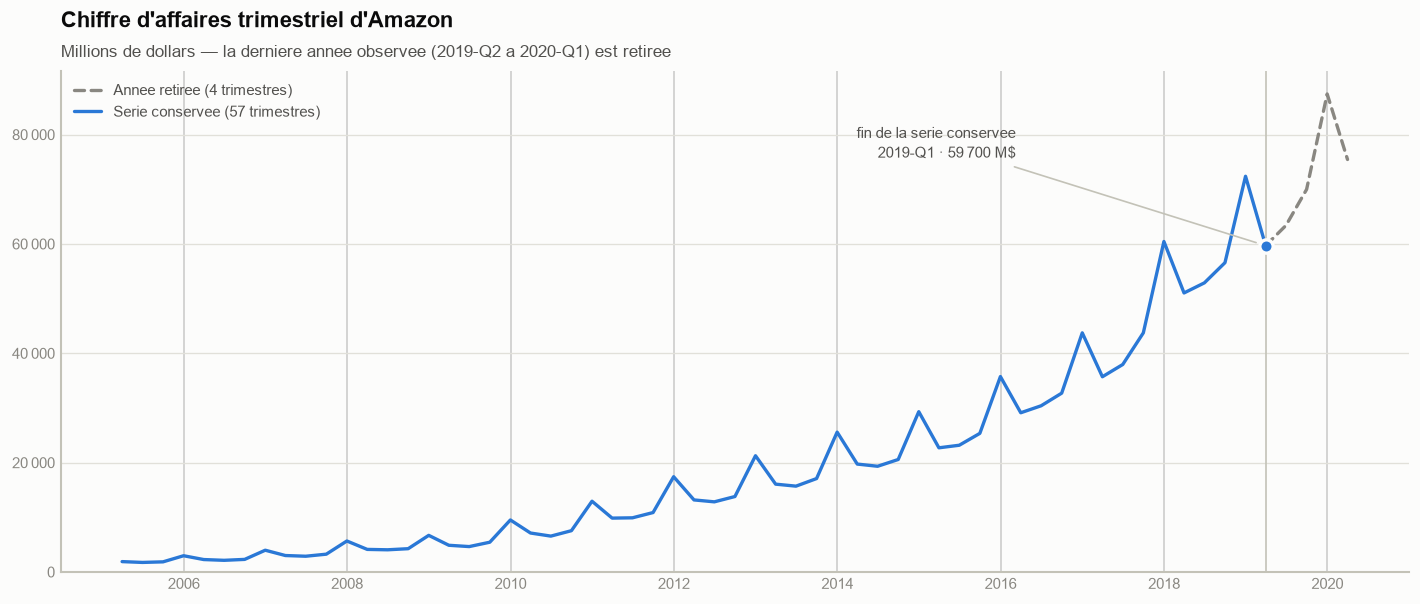

In [9]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Palette (mode clair) ---
ACCENT  = "#2a78d6"   # serie conservee
MUTED   = "#898781"   # annee retiree (de-emphase) + libelles d'axes
SURFACE = "#fcfcfb"
GRID    = "#e1e0d9"
AXIS    = "#c3c2b7"
INK     = "#0b0b0b"
INK_2   = "#52514e"

espace = lambda v: f"{v:,.0f}".replace(",", " ")  # separateur de milliers

# on rattache le dernier point conserve au segment retire : ligne continue
retire_relie = df_complet.iloc[len(df_reduit) - 1:]

fig, ax = plt.subplots(figsize=(12, 5.2), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(retire_relie.index, retire_relie["Revenue"], color=MUTED, lw=2,
        ls=(0, (3, 2)), dash_capstyle="round", zorder=2,
        label="Annee retiree (4 trimestres)")
ax.plot(df_reduit.index, df_reduit["Revenue"], color=ACCENT, lw=2,
        solid_capstyle="round", solid_joinstyle="round", zorder=3,
        label="Serie conservee (57 trimestres)")

# Point de coupure : marqueur cercle avec anneau couleur surface
x_fin, y_fin = df_reduit.index[-1], df_reduit["Revenue"].iloc[-1]
ax.axvline(x_fin, color=AXIS, lw=1, zorder=1)
ax.plot(x_fin, y_fin, "o", ms=8, mfc=ACCENT, mec=SURFACE, mew=2, zorder=4)
ax.annotate(f"fin de la serie conservee\n2019-Q1 · {espace(y_fin)} M$",
            xy=(x_fin, y_fin), xytext=(-150, 62), textcoords="offset points",
            ha="right", va="center", fontsize=9, color=INK_2, linespacing=1.4,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=1, shrinkA=2, shrinkB=6))

# Chrome recessif
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(AXIS)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: espace(v)))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(0, None)

ax.set_title("Chiffre d'affaires trimestriel d'Amazon", loc="left",
             color=INK, fontsize=13, fontweight="semibold", pad=26)
ax.text(0, 1.02, "Millions de dollars — la derniere annee observee (2019-Q2 a 2020-Q1) est retiree",
        transform=ax.transAxes, color=INK_2, fontsize=10, va="bottom")

leg = ax.legend(frameon=False, loc="upper left", fontsize=9, handlelength=1.8)
for t in leg.get_texts():
    t.set_color(INK_2)

plt.tight_layout()
plt.show()

## 2. Test ANOVA

ANOVA à deux facteurs sur la série tronquée : **année** (tendance) et **trimestre**
(saisonnalité). Les deux facteurs sont testés ensemble — testée seule, la saisonnalité
serait noyée dans la variance de la tendance.

In [10]:
from scipy import stats

# ANOVA a 2 facteurs : Annee (tendance) + Trimestre (saisonnalite).
# Sur log(Revenue) : la variance croit avec le niveau, le log la stabilise.
a = df_reduit.copy()
a["log_rev"] = np.log(a["Revenue"])
a["annee"] = a.index.year
a["trimestre"] = a.index.quarter

# Plan equilibre : annees completes uniquement (1 observation par cellule annee x trimestre)
n_obs = a.groupby("annee")["log_rev"].count()
a = a[a["annee"].isin(n_obs[n_obs == 4].index)]
n_an, n_tr = a["annee"].nunique(), 4

x, m = a["log_rev"], a["log_rev"].mean()
SS_an = n_tr * ((a.groupby("annee")["log_rev"].mean() - m) ** 2).sum()
SS_tr = n_an * ((a.groupby("trimestre")["log_rev"].mean() - m) ** 2).sum()
SS_tot = ((x - m) ** 2).sum()
SS_res = SS_tot - SS_an - SS_tr
ddl = [n_an - 1, n_tr - 1, (n_an - 1) * (n_tr - 1)]
MS_res = SS_res / ddl[2]

anova = pd.DataFrame({"SS": [SS_an, SS_tr, SS_res], "ddl": ddl},
                     index=["Annee (tendance)", "Trimestre (saison)", "Residu"])
anova["MS"] = anova["SS"] / anova["ddl"]
anova["F"] = anova["MS"] / MS_res
anova["p"] = [stats.f.sf(anova["F"].iloc[i], ddl[i], ddl[2]) for i in range(2)] + [np.nan]
anova["% var"] = anova["SS"] / SS_tot * 100
anova.loc["Residu", ["F", "p"]] = np.nan

print(f"ANOVA a 2 facteurs sur log(Revenue) : {len(a)} observations, "
      f"{n_an} annees x {n_tr} trimestres\n")
display(anova.round({"SS": 3, "MS": 4, "F": 1, "% var": 1}))

for nom in anova.index[:2]:
    p = anova.loc[nom, "p"]
    verdict = "SIGNIFICATIF" if p < 0.05 else "non significatif"
    print(f"{nom:<20s} F = {anova.loc[nom, 'F']:8.1f}   p = {p:.2e}   -> {verdict} (alpha = 5 %)")

ANOVA a 2 facteurs sur log(Revenue) : 56 observations, 14 annees x 4 trimestres



,SS,ddl,MS,F,p,% var
Annee (tendance),59.221,13,4.5555,1354.7,1.614252e-47,95.7
Trimestre (saison),2.517,3,0.8390,249.5,1.753953e-25,4.1
Residu,0.131,39,0.0034,NaN,NaN,0.2


Annee (tendance)     F =   1354.7   p = 1.61e-47   -> SIGNIFICATIF (alpha = 5 %)
Trimestre (saison)   F =    249.5   p = 1.75e-25   -> SIGNIFICATIF (alpha = 5 %)


**Les deux effets sont significatifs.** La tendance explique **95,7 %** de la variance de
`log(Revenue)`, la saisonnalité **4,1 %**, le résidu 0,2 %. La série est donc à modéliser avec
tendance *et* saison (SARIMA, Holt-Winters), pas l'une puis l'autre.